# Stochastic Logistic Regression — 30-Day Readmission Prediction
**Diabetes 130-US Hospitals (1999–2008)**  
Pipeline: Data loading → Preprocessing → Training → Evaluation → Fairness Audit

## 1. Imports & Setup

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
    recall_score, precision_score
)
from ucimlrepo import fetch_ucirepo

# Output directories
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir   = os.path.join(PROJECT_ROOT, "outputs", "sto_logreg")
graph_dir    = os.path.join(PROJECT_ROOT, "graphs",  "sto_logreg")
os.makedirs(output_dir, exist_ok=True)
os.makedirs(graph_dir,  exist_ok=True)

## 2. Load & Preprocess Data
Fetch directly from UCI ML Repository. The dataset has 101,766 rows and 50 columns.  
Key steps:
- Drop high-missing and ID columns  
- Remove expired/hospice patients (cannot be readmitted)  
- Replace `?` with NaN, impute, one-hot encode  
- Binarize target: `1` if readmitted `<30` days, else `0`

In [ ]:
def load_data():
    print("Loading dataset...")
    raw = fetch_ucirepo(id=296)
    X   = raw.data.features.copy()
    y   = raw.data.targets.copy()

    # Binarize target
    y = (y['readmitted'] == '<30').astype(int).values

    # Drop unusable columns
    cols_to_drop = [
        'weight', 'payer_code', 'medical_specialty',
        'encounter_id', 'patient_nbr',
        'diag_1', 'diag_2', 'diag_3',   # high cardinality ICD codes
    ]
    X = X.drop(columns=[c for c in cols_to_drop if c in X.columns])

    # Remove patients who cannot be readmitted (expired / hospice)
    if 'discharge_disposition_id' in X.columns:
        dead_codes = [11, 13, 14, 19, 20, 21]
        mask = ~X['discharge_disposition_id'].isin(dead_codes)
        X, y = X[mask], y[mask]

    # Replace '?' with NaN
    X = X.replace('?', np.nan)

    # Drop columns with >40% missing
    missing_frac = X.isnull().mean()
    X = X.drop(columns=missing_frac[missing_frac > 0.4].index)

    # Separate numeric and categorical
    num_cols = X.select_dtypes(include=[np.number]).columns
    cat_cols = X.select_dtypes(exclude=[np.number]).columns

    # Drop high-cardinality categoricals (>20 unique values)
    high_card = [c for c in cat_cols if X[c].nunique() > 20]
    X = X.drop(columns=high_card)
    cat_cols = [c for c in cat_cols if c not in high_card]

    # Impute
    X[num_cols] = X[num_cols].fillna(X[num_cols].median())
    X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

    # Save demographic columns BEFORE encoding (needed for fairness audit)
    demo_cols = X[['race', 'gender', 'age']].copy() if 'race' in X.columns else None

    # One-hot encode
    X = pd.get_dummies(X, columns=list(cat_cols), drop_first=True)

    print(f"Final dataset: {X.shape[0]} rows, {X.shape[1]} features")
    print(f"Positive class (readmitted <30d): {y.mean()*100:.1f}%")
    return X, y, demo_cols

X, y, demo_raw = load_data()

Loading dataset...


/Users/jaydenchen/Downloads/ML/final_proj/Middlebury-ML-Class-Proj/.venv/lib/python3.13/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)


Final dataset: 99343 rows, 76 features
Positive class (readmitted <30d): 11.4%


## 3. Class Distribution
Check the target imbalance before splitting. The positive class (~11%) is the minority — 
this directly motivates using `pos_weight` in the loss function.

Class 0 (not readmitted <30d): 88029
Class 1 (readmitted <30d):     11314
Ratio: 7.78 : 1


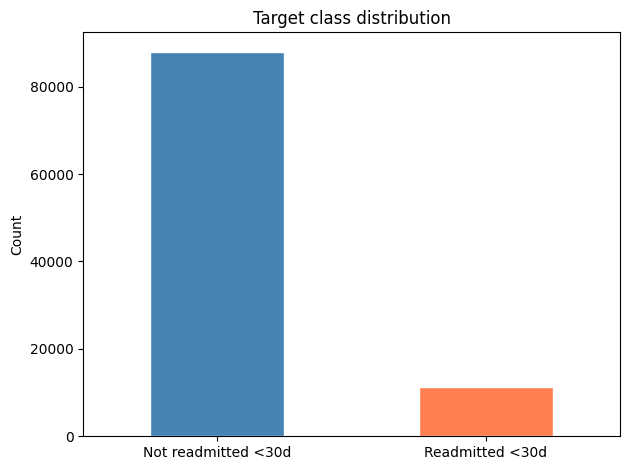

In [16]:
unique, counts = np.unique(y, return_counts=True)
print("Class 0 (not readmitted <30d):", counts[0])
print("Class 1 (readmitted <30d):    ", counts[1])
print(f"Ratio: {counts[0]/counts[1]:.2f} : 1")

pd.Series(y).value_counts().plot(kind='bar', title='Target class distribution',
                                  color=['steelblue','coral'], edgecolor='white')
plt.xticks([0, 1], ['Not readmitted <30d', 'Readmitted <30d'], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4. Train/Test Split & Scaling
- Stratified 80/20 split preserves the class ratio in both sets  
- `StandardScaler` normalises features to mean=0, std=1 — critical for gradient-based training  
- Scaler is fit **only** on training data to prevent data leakage

In [ ]:
def split_and_scale(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    feature_cols = list(X_train.columns)   # save for fairness audit
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, scaler, feature_cols

X_train, X_test, y_train, y_test, scaler, feature_cols = split_and_scale(X, y)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Positive rate — train: {y_train.mean():.3f}  test: {y_test.mean():.3f}")

Train: (79474, 76)  |  Test: (19869, 76)
Positive rate — train: 0.114  test: 0.114


## Model - Stochastic Logistic Regression
A single linear layer trained with mini-batch stochastic gradient descent via Adam. Logistic regression implemented in PyTorch. 

In [ ]:
class StochasticLogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)
        nn.init.xavier_uniform_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x):
        return self.linear(x) 


class EarlyStopping:
    """Stop training when validation loss stops improving."""
    def __init__(self, patience=5, min_delta=1e-4):
        self.patience    = patience
        self.min_delta   = min_delta
        self.best_loss   = float('inf')
        self.counter     = 0
        self.should_stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter   = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

## 6. Training
`pos_weight` upweights the minority class so the model doesn't trivially predict the majority.  
Weight = (# negatives) / (# positives) ≈ 6–7× for this dataset.

In [6]:
def train(X_train, y_train, pos_weight_val, batch_size=256, epochs=50, lr=1e-3):
    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)

    model     = StochasticLogisticRegression(X_train.shape[1])
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []

    print(f"Training: {epochs} epochs | batch={batch_size} | lr={lr} | pos_weight={pos_weight_val:.2f}")
    print("-" * 55)

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs} — loss: {avg_loss:.4f}")

    return model, history

n_neg          = (y_train == 0).sum()
n_pos          = (y_train == 1).sum()
pos_weight_val = n_neg / n_pos
print(f"Class weight (pos_weight): {pos_weight_val:.2f}")

model, history = train(X_train, y_train, pos_weight_val=pos_weight_val,
                       batch_size=256, epochs=50, lr=1e-3)

Class weight (pos_weight): 7.78
Training: 50 epochs | batch=256 | lr=0.001 | pos_weight=7.78
-------------------------------------------------------
  Epoch  10/50 — loss: 1.1699
  Epoch  20/50 — loss: 1.1687
  Epoch  30/50 — loss: 1.1685
  Epoch  40/50 — loss: 1.1684
  Epoch  50/50 — loss: 1.1681


## 7. Training Loss Curve

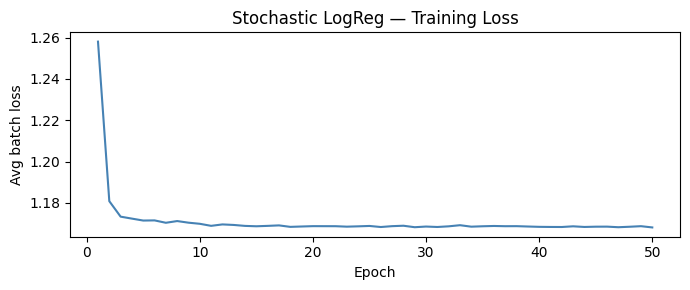

Saved: training_loss.png


In [7]:
plt.figure(figsize=(7, 3))
plt.plot(range(1, len(history) + 1), history, color='steelblue', linewidth=1.5)
plt.xlabel('Epoch')
plt.ylabel('Avg batch loss')
plt.title('Stochastic LogReg — Training Loss')
plt.tight_layout()
plt.savefig(os.path.join(graph_dir, "training_loss.png"), dpi=150)
plt.show()
print("Saved: training_loss.png")

## 8. Evaluation
Metrics at default threshold τ = 0.5:
- **Sensitivity (Recall):** fraction of true readmissions caught  
- **PPV (Precision):** fraction of flagged patients who truly were readmitted  
- **AUROC:** overall ranking quality across all thresholds

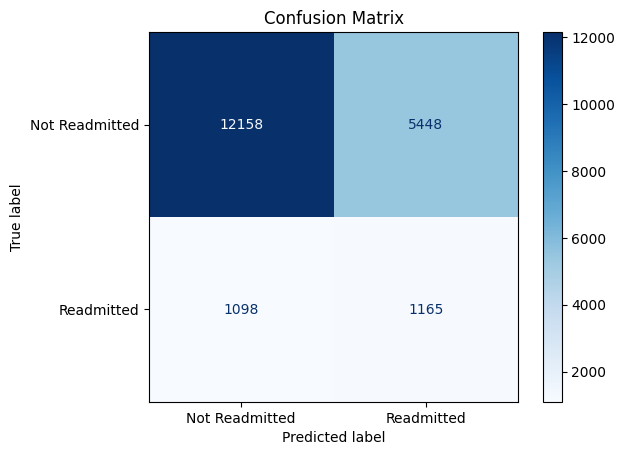


--- Evaluation (threshold = 0.5) ---
  Sensitivity (Recall): 0.5148
  PPV (Precision):      0.1762
  AUROC:                0.6461
  TN= 12158  FP=  5448
  FN=  1098  TP=  1165


In [8]:
def evaluate(model, X_test, y_test, threshold=0.5):
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.tensor(X_test, dtype=torch.float32))).squeeze().numpy()

    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()

    # Confusion matrix plot
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, preds, labels=[0, 1]),
        display_labels=['Not Readmitted', 'Readmitted']
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.savefig(os.path.join(graph_dir, "confusion_matrix.png"), dpi=180)
    plt.show()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    ppv         = tp / (tp + fp) if (tp + fp) > 0 else 0
    auroc       = roc_auc_score(y_test, probs)

    print(f"\n--- Evaluation (threshold = {threshold}) ---")
    print(f"  Sensitivity (Recall): {sensitivity:.4f}")
    print(f"  PPV (Precision):      {ppv:.4f}")
    print(f"  AUROC:                {auroc:.4f}")
    print(f"  TN={tn:6d}  FP={fp:6d}")
    print(f"  FN={fn:6d}  TP={tp:6d}")
    return probs, {'sensitivity': sensitivity, 'ppv': ppv, 'auroc': auroc}

probs, metrics = evaluate(model, X_test, y_test, threshold=0.5)

## 9. Threshold Sweep
Varying the decision threshold τ shows the precision-recall tradeoff.  
The default τ=0.5 is arbitrary — the clinical optimum depends on the relative  
cost of false negatives (missed readmissions) vs false positives (unnecessary interventions).

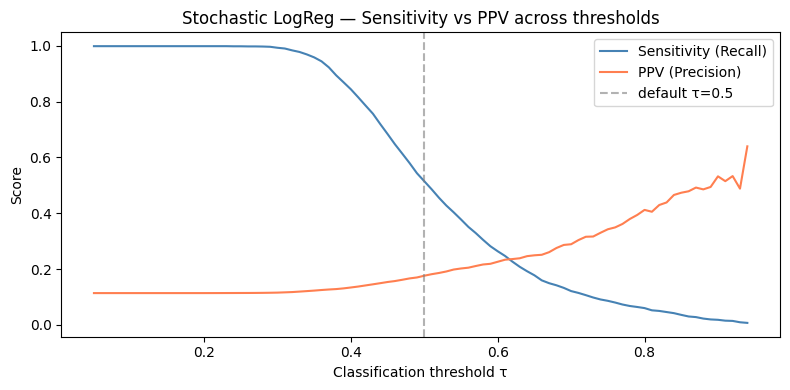

In [9]:
thresholds    = np.arange(0.05, 0.95, 0.01)
sensitivities = []
ppvs          = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    if preds.sum() == 0:
        sensitivities.append(0); ppvs.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    sensitivities.append(tp / (tp + fn + 1e-9))
    ppvs.append(tp / (tp + fp + 1e-9))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, sensitivities, label='Sensitivity (Recall)', color='steelblue')
plt.plot(thresholds, ppvs,          label='PPV (Precision)',      color='coral')
plt.axvline(0.5, linestyle='--', color='gray', alpha=0.6, label='default τ=0.5')
plt.xlabel('Classification threshold τ')
plt.ylabel('Score')
plt.title('Stochastic LogReg — Sensitivity vs PPV across thresholds')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(graph_dir, "threshold_sweep.png"), dpi=150)
plt.show()

## 10. Save Model Artifacts

In [10]:
with open(os.path.join(output_dir, "model.pkl"), "wb") as f:
    pickle.dump(model, f)

with open(os.path.join(output_dir, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(output_dir, "feature_cols.pkl"), "wb") as f:
    pickle.dump(feature_cols, f)

# Save test split for standalone fairness audit
if demo_raw is not None:
    idx = np.arange(len(y))
    idx_train, idx_test = train_test_split(
        idx, test_size=0.2, random_state=42, stratify=y
    )
    demo_raw.iloc[idx_test].reset_index(drop=True).to_csv(
        os.path.join(output_dir, "demo_test.csv"), index=False
    )
    pd.Series(y_test).to_csv(
        os.path.join(output_dir, "y_test.csv"), index=False, header=True
    )

print("Saved: model.pkl, scaler.pkl, feature_cols.pkl, demo_test.csv, y_test.csv")

Saved: model.pkl, scaler.pkl, feature_cols.pkl, demo_test.csv, y_test.csv


## 11. Fairness Audit
Disaggregate AUROC, Recall, and Positive Prediction Rate by demographic subgroup.  
Gaps ≥ 0.05 AUROC between best and worst subgroup are flagged as disparities.  
This is the equity analysis missing from published benchmarks on this dataset.

In [11]:
# ── Inline FairnessAuditor (no external import needed in notebook) ────────────
class FairnessAuditor:
    SUBGROUPS  = {"Race": "race", "Gender": "gender"}
    AGE_LABELS = {
        0:"[0-10)", 1:"[10-20)", 2:"[20-30)", 3:"[30-40)", 4:"[40-50)",
        5:"[50-60)", 6:"[60-70)", 7:"[70-80)", 8:"[80-90)", 9:"[90-100)"
    }

    def __init__(self, X_demo, y_test, threshold=0.5, gap=0.05):
        self.X       = X_demo.reset_index(drop=True).copy()
        self.y       = np.array(y_test)
        self.t       = threshold
        self.gap     = gap
        self.models  = {}
        self.results = {}

    def add_model(self, name, probs):
        self.models[name] = np.array(probs)

    def _metrics(self, mask, probs):
        y, p = self.y[mask], probs[mask]
        if len(y) < 30 or y.sum() < 5:
            return None
        preds = (p >= self.t).astype(int)
        try:    auroc = roc_auc_score(y, p)
        except: auroc = np.nan
        return {
            "n":          int(mask.sum()),
            "prevalence": round(y.mean(), 4),
            "auroc":      round(auroc, 4),
            "recall":     round(recall_score(y, preds, zero_division=0), 4),
            "precision":  round(precision_score(y, preds, zero_division=0), 4),
            "ppr":        round(preds.mean(), 4),
        }

    def run_audit(self):
        for name, probs in self.models.items():
            self.results[name] = {}
            print(f"\n{'='*60}\n  {name}  |  Overall AUROC={roc_auc_score(self.y, probs):.4f}\n{'='*60}")
            for label, col in self.SUBGROUPS.items():
                if col not in self.X.columns: continue
                rows = []
                for val in sorted(self.X[col].dropna().unique()):
                    m = self._metrics((self.X[col] == val).values, probs)
                    if m: rows.append({"subgroup": str(val), **m})
                if not rows: continue
                df   = pd.DataFrame(rows).set_index("subgroup")
                best = df["auroc"].max()
                self.results[name][label] = df
                print(f"\n  ── {label}")
                for sg, row in df.iterrows():
                    flag = " !" if (best - row["auroc"]) >= self.gap else ""
                    print(f"    {sg:<20} N={row['n']:<6} AUROC={row['auroc']:.3f}  "
                          f"Recall={row['recall']:.3f}  PPR={row['ppr']:.3f}{flag}")
        return self.results

    def summary(self):
        print(f"\n{'='*50}\n  Max AUROC Gap by Subgroup\n{'='*50}")
        for name in self.models:
            for label, df in self.results.get(name, {}).items():
                gap  = df["auroc"].max() - df["auroc"].min()
                print(f"  {name:<22} {label:<10} gap={gap:.4f}  "
                      f"flagged={'! YES' if gap >= self.gap else 'no'}")

    def plot_audit(self, save_path=None):
        labels = [l for l in self.SUBGROUPS if any(
            l in self.results.get(m, {}) for m in self.models)]
        colors = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0"]
        fig, axes = plt.subplots(len(labels), 1, figsize=(14, 5 * len(labels)))
        if len(labels) == 1: axes = [axes]
        for ax, label in zip(axes, labels):
            subgroups = list(dict.fromkeys(
                sg for m in self.models
                for sg in self.results.get(m, {}).get(label, pd.DataFrame()).index))
            x     = np.arange(len(subgroups))
            width = 0.8 / len(self.models)
            for i, (name, color) in enumerate(zip(self.models, colors)):
                df     = self.results.get(name, {}).get(label, pd.DataFrame())
                aurocs = [df.loc[sg, "auroc"] if sg in df.index else np.nan for sg in subgroups]
                offset = (i - len(self.models) / 2 + 0.5) * width
                bars   = ax.bar(x + offset, aurocs, width * 0.9, label=name,
                                color=color, alpha=0.85, edgecolor="white")
                for bar, val in zip(bars, aurocs):
                    if not np.isnan(val):
                        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.003,
                                f"{val:.3f}", ha="center", va="bottom", fontsize=7)
            ax.set_xticks(x); ax.set_xticklabels(subgroups, rotation=30, ha="right")
            ax.set_ylabel("AUROC"); ax.set_title(f"AUROC by {label}", fontweight="bold")
            ax.set_ylim(0.45, 0.85)
            ax.axhline(0.5, color="red", linewidth=0.8, linestyle="--", alpha=0.5)
            ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
            ax.spines[["top","right"]].set_visible(False)
        fig.suptitle("Fairness Audit — AUROC by Demographic Subgroup", fontsize=13, fontweight="bold")
        plt.tight_layout()
        if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.show()


  Stochastic LogReg  |  Overall AUROC=0.6461

  ── Race
    AfricanAmerican      N=3809.0 AUROC=0.636  Recall=0.504  PPR=0.331 !
    Asian                N=128.0  AUROC=0.782  Recall=0.550  PPR=0.227
    Caucasian            N=15218.0 AUROC=0.646  Recall=0.519  PPR=0.338 !
    Hispanic             N=410.0  AUROC=0.743  Recall=0.625  PPR=0.285
    Other                N=304.0  AUROC=0.556  Recall=0.300  PPR=0.217 !

  ── Gender
    Female               N=10651.0 AUROC=0.632  Recall=0.495  PPR=0.332
    Male                 N=9218.0 AUROC=0.662  Recall=0.537  PPR=0.334

  Max AUROC Gap by Subgroup
  Stochastic LogReg      Race       gap=0.2256  flagged=! YES
  Stochastic LogReg      Gender     gap=0.0308  flagged=no


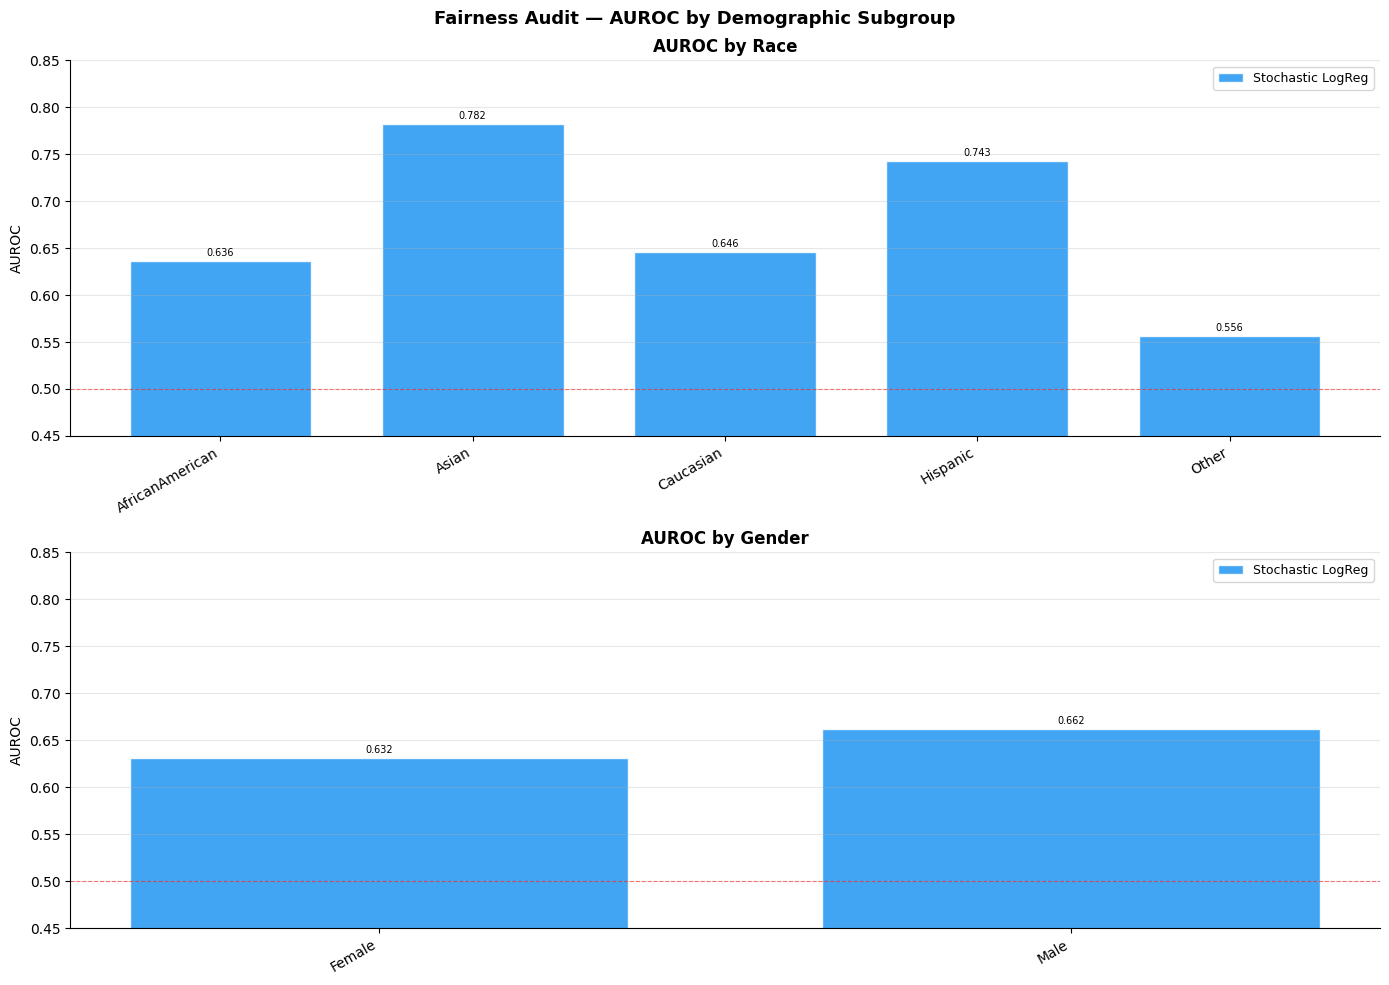

In [12]:
# ── Run the audit ─────────────────────────────────────────────────────────────
# demo_raw contains race and gender for all rows — slice the test portion
_, X_idx_test = train_test_split(np.arange(len(y)), test_size=0.2,
                                  random_state=42, stratify=y)

demo_test_df = demo_raw.iloc[X_idx_test].reset_index(drop=True) if demo_raw is not None else None

if demo_test_df is not None:
    auditor = FairnessAuditor(demo_test_df, y_test, threshold=0.5, gap=0.05)
    auditor.add_model("Stochastic LogReg", probs)
    auditor.run_audit()
    auditor.summary()
    auditor.plot_audit(save_path=os.path.join(graph_dir, "fairness_audit.png"))
else:
    print("demo_raw not available — re-run load_data() to capture demographic columns.")

## 12. Results Summary

In [13]:
print("=" * 45)
print("  FINAL RESULTS — Stochastic Logistic Regression")
print("=" * 45)
print(f"  AUROC:                {metrics['auroc']:.4f}")
print(f"  Sensitivity (Recall): {metrics['sensitivity']:.4f}")
print(f"  PPV (Precision):      {metrics['ppv']:.4f}")
print(f"  Features used:        {len(feature_cols)}")
print(f"  Training samples:     {X_train.shape[0]:,}")
print(f"  Test samples:         {X_test.shape[0]:,}")

  FINAL RESULTS — Stochastic Logistic Regression
  AUROC:                0.6461
  Sensitivity (Recall): 0.5148
  PPV (Precision):      0.1762
  Features used:        76
  Training samples:     79,474
  Test samples:         19,869
